## Proportion of Current Cigarette Use by Psychological State
## 不同心理狀態之目前吸菸比例馬賽克圖

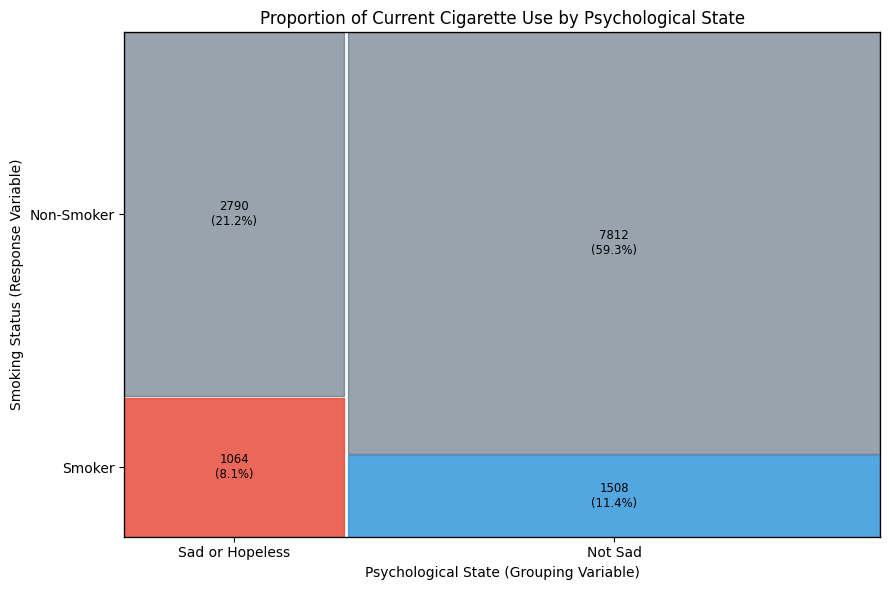

In [12]:
import os
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

# 檢查並自動建立符合專案規範的圖表輸出資料夾
# Check and automatically create the standard output directory for figures
os.makedirs('outputs/figures', exist_ok=True)

# 載入根據清洗後資料所計算出的真實交叉人數
# Load the real cross-tabulation counts calculated from cleaned_data.csv
data_dict = {
    ('Sad or Hopeless', 'Smoker'): 1064,
    ('Sad or Hopeless', 'Non-Smoker'): 2790,
    ('Not Sad', 'Smoker'): 1508,
    ('Not Sad', 'Non-Smoker'): 7812
}

# 設定每個區塊的顏色與透明度屬性
# Define color and alpha properties for each specific block
def assign_color(key):
    group, status = key
    if status == 'Smoker':
        if group == 'Not Sad':
            return {'color': '#3498db', 'alpha': 0.85}
        else:
            return {'color': '#e74c3c', 'alpha': 0.85}
    else:
        return {'color': '#34495e', 'alpha': 0.5}

# 建立圖表物件並繪製馬賽克圖
# Create the figure object and plot the mosaic chart
fig, ax = plt.subplots(figsize=(9, 6))
mosaic(data_dict, ax=ax, properties=assign_color,
       title='Proportion of Current Cigarette Use by Psychological State',
       labelizer=lambda k: f"{data_dict[k]}\n({data_dict[k]/sum(data_dict.values())*100:.1f}%)" if 'Smoker' in k[1] else f"{data_dict[k]}")

# 設定 X 軸與 Y 軸的英文標籤
# Set English labels for the X and Y axes
ax.set_xlabel('Psychological State (Grouping Variable)')
ax.set_ylabel('Smoking Status (Response Variable)')
plt.tight_layout()

# 將圖表自動匯出並儲存為高解析度圖片檔案
# Automatically export and save the chart as a high-resolution image file
plt.savefig('outputs/figures/mosaic_plot.png', dpi=300, bbox_inches='tight')
plt.show()

The width of the columns represents the total sample size of each group (the "Not Sad" group on the right is the majority).

The height represents the proportion, with the red blocks specifically indicating "smokers."

Despite the "Sad" group (left) having fewer total students, the vertical proportion of its red smoker block (27.6%) is noticeably taller than that of the "Not Sad" group (16.2%).

This visually highlights a strong trend: **students who feel sad or hopeless have a notably higher tendency to smoke.**

---
這張圖同時呈現了「人數多寡」與「吸菸比例」。圖表的寬度代表該群體的總人數（右側不悲傷組佔了絕大多數）；高度則代表比例，紅色區塊專指「有吸菸」的學生。

比較左右兩側可以直觀地發現，儘管「悲傷組（左）」的總人數較少，但其紅色吸菸區塊的垂直佔比（27.6%）明顯比「不悲傷組（右）」的紅色區塊（16.2%）還要高。這在視覺上強烈暗示：**感到悲傷的學生，擁有明顯較高的吸菸傾向**。


## Sampling Distributions: Visualizing the Group Difference
## 抽樣分配模型與群體差異探討圖

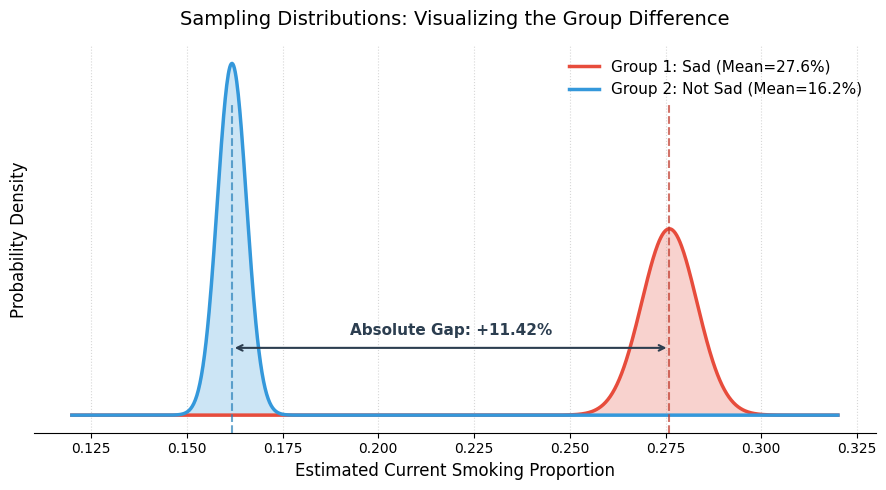

In [13]:
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# 檢查並自動建立符合專案規範的圖表輸出資料夾
# Check and automatically create the standard output directory for figures
os.makedirs('outputs/figures', exist_ok=True)

# 載入數據與計算標準誤，用以建構理論抽樣分配
# Load data and compute standard errors to construct theoretical sampling distributions
p1, n1 = 0.2760, 3854
p2, n2 = 0.1618, 9320
se1 = np.sqrt(p1 * (1 - p1) / n1)
se2 = np.sqrt(p2 * (1 - p2) / n2)

# 建立 X 軸範圍以涵蓋兩個群組的分配曲線
# Define X-axis range to encompass distribution curves for both groups
x = np.linspace(0.12, 0.32, 1000)
y1 = stats.norm.pdf(x, p1, se1)
y2 = stats.norm.pdf(x, p2, se2)

# 初始化圖表並建立座標軸物件
# Initialize figure and create axes object
fig, ax = plt.subplots(figsize=(9, 5))

# 繪製並填滿 Group 1 (悲傷組) 的常態分配曲線
# Plot and fill the normal distribution curve for Group 1 (Sad)
ax.plot(x, y1, color='#e74c3c', linewidth=2.5, label=f'Group 1: Sad (Mean={p1*100:.1f}%)')
ax.fill_between(x, y1, alpha=0.25, color='#e74c3c')

# 繪製並填滿 Group 2 (不悲傷組) 的常態分配曲線
# Plot and fill the normal distribution curve for Group 2 (Not Sad)
ax.plot(x, y2, color='#3498db', linewidth=2.5, label=f'Group 2: Not Sad (Mean={p2*100:.1f}%)')
ax.fill_between(x, y2, alpha=0.25, color='#3498db')

# 標示群組平均數的垂直虛線以突出兩組中心點
# Draw vertical dashed lines at group means to highlight centers
ax.axvline(p1, color='#c0392b', linestyle='--', alpha=0.7, ymax=0.85)
ax.axvline(p2, color='#2980b9', linestyle='--', alpha=0.7, ymax=0.85)

# 在兩條虛線之間繪製雙向箭頭與絕對差距文字標籤
# Annotate with a double-headed arrow and absolute gap text label between lines
ax.annotate('', xy=(p1, 20), xytext=(p2, 20),
            arrowprops=dict(arrowstyle='<->', color='#2c3e50', lw=1.5))
ax.text((p1+p2)/2, 23, f'Absolute Gap: +{(p1-p2)*100:.2f}%',
        ha='center', va='bottom', fontsize=11, color='#2c3e50', fontweight='bold')

# 設定純英文的圖表標題與軸標籤
# Set pure English main title and axis labels
ax.set_title("Sampling Distributions: Visualizing the Group Difference", fontsize=14, pad=15)
ax.set_xlabel("Estimated Current Smoking Proportion", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)

# 移除上方、右側與左側的邊框線條，隱藏 Y 軸數字以保持簡潔
# Remove top, right, and left borders, and hide Y-axis values for maximum clarity
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])

# 去除圖例的外框背景，使整體視覺更乾淨
# Remove the legend frame background for a cleaner academic presentation
ax.legend(loc='upper right', frameon=False, fontsize=11)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()

# 將圖表自動匯出並儲存為高解析度圖片檔案
# Automatically export and save the chart as a high-resolution image file
plt.savefig('outputs/figures/density_curves.png', dpi=300, bbox_inches='tight')
plt.show()

This plot translates the smoking rate estimates into normal distribution curves.

The narrower and taller the curve, the more precise our estimate is (due to a tiny standard error).

The center arrow quantifies the absolute gap between the two group means.

The two bell curves are completely separated with zero overlap along the X-axis, spanning a massive absolute gap of 11.42%.

This not only confirms statistical significance but also highlights the immense practical significance of this gap demonstrating a profound and undeniable association between sad feelings and adolescent smoking behavior.

---
這裡將吸菸率的估計值轉換為「常態分佈曲線」。曲線越「瘦高」，代表我們的估計越精準（標準誤極小）。

中間的箭頭與數字則量化了兩組平均數的絕對差距。

這兩座代表不同群體的鐘型曲線在 X 軸上「完全分離、零重疊」，並且中間橫跨了高達 11.42% 的絕對差距。這不僅再次確認了統計顯著性，更強調了這個差異的「實質影響力 (Practical Significance)」極大悲傷情緒與青少年吸菸行為之間，確實存在著不容忽視的巨大鴻溝。

## The Risk Escalator: Smoking Probability by Comorbidity
## 風險階梯：身心狀態與飲酒行為對吸菸機率的疊加效應





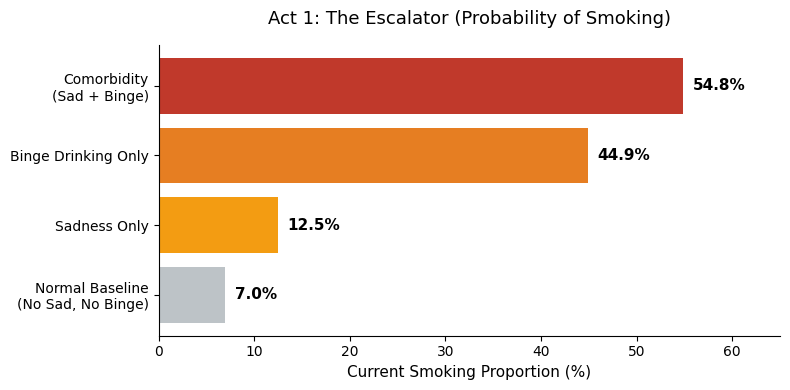

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 確保輸出資料夾存在
os.makedirs('outputs/figures', exist_ok=True)

# 讀取包含四個變數的乾淨資料集
df = pd.read_csv('cleaned_data.csv')

# ==========================================
# 📊 圖一數據：正向機率 (吸菸率) - 毒性階梯
# ==========================================
g_nosad_nobinge = df[(df['SadOrHopeless_Recoded']==0) & (df['CurrentBingeDrinking5OrMore_Recoded']==0)]['CurrentCigaretteUse_Recoded'].mean() * 100
g_sad_nobinge = df[(df['SadOrHopeless_Recoded']==1) & (df['CurrentBingeDrinking5OrMore_Recoded']==0)]['CurrentCigaretteUse_Recoded'].mean() * 100
g_nosad_binge = df[(df['SadOrHopeless_Recoded']==0) & (df['CurrentBingeDrinking5OrMore_Recoded']==1)]['CurrentCigaretteUse_Recoded'].mean() * 100
g_sad_binge = df[(df['SadOrHopeless_Recoded']==1) & (df['CurrentBingeDrinking5OrMore_Recoded']==1)]['CurrentCigaretteUse_Recoded'].mean() * 100

fig1, ax1 = plt.subplots(figsize=(8, 4))
labels_1 = ['Normal Baseline\n(No Sad, No Binge)', 'Sadness Only', 'Binge Drinking Only', 'Comorbidity\n(Sad + Binge)']
values_1 = [g_nosad_nobinge, g_sad_nobinge, g_nosad_binge, g_sad_binge]
colors_1 = ['#bdc3c7', '#f39c12', '#e67e22', '#c0392b'] # 灰 -> 黃 -> 橘 -> 紅

bars = ax1.barh(labels_1, values_1, color=colors_1)
ax1.set_title('Act 1: The Escalator (Probability of Smoking)', fontsize=13, pad=15)
ax1.set_xlabel('Current Smoking Proportion (%)', fontsize=11)
ax1.set_xlim(0, 65)

for bar in bars:
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', fontweight='bold', fontsize=11)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/figures/act1_escalator.png', dpi=300)

This chart illustrates the smoking proportion among students across four combinations of psychological states (Sad/Not Sad) and drinking behaviors (Binge/No Binge).

The data reveals a clear "escalating" pattern. Smoking risk is not dictated by a single factor but exhibits an additive trend. Starting from the baseline (7.0%), each additional risk factor—sadness or binge drinking—significantly raises smoking prevalence. When both "sadness" and "binge drinking" coexist, smoking rates skyrocket to 54.8%, confirming the potent cumulative effect of multiple high-risk behaviors.


---
這張圖展示了在不同心理狀態（悲傷 vs. 不悲傷）與飲酒行為（有狂飲 vs. 無狂飲）的四種組合下，學生的吸菸比例。

數據揭示了一個明顯的「階梯式上升」現象。吸菸風險並非由單一因子決定，而是呈現加乘趨勢。從不悲傷且無狂飲的「普通學生基線 (7.0%)」，每增加一個負面因子（如悲傷或狂飲），吸菸機率便顯著攀升。當「悲傷」與「狂飲」兩大風險因子同時存在時，吸菸率飆升至 54.8%，證實了多重風險行為具有強大的疊加效應。


## The Beacon: Probability of Feeling Sad or Hopeless by Deviant Behavior

## 雷達信標：從偏差行為反向推估學生的悲傷濃度

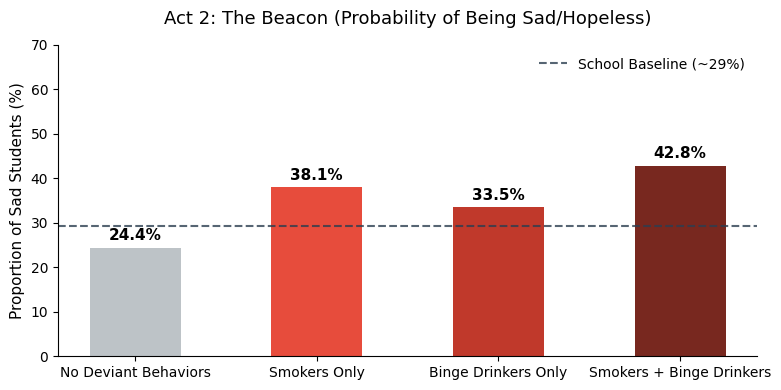

In [15]:
# ==========================================
# 🚨 圖二數據：反向溯源 (悲傷濃度) - 尋找信標
# ==========================================
sad_in_none = df[(df['CurrentCigaretteUse_Recoded']==0) & (df['CurrentBingeDrinking5OrMore_Recoded']==0)]['SadOrHopeless_Recoded'].mean() * 100
sad_in_smoke = df[(df['CurrentCigaretteUse_Recoded']==1) & (df['CurrentBingeDrinking5OrMore_Recoded']==0)]['SadOrHopeless_Recoded'].mean() * 100
sad_in_binge = df[(df['CurrentCigaretteUse_Recoded']==0) & (df['CurrentBingeDrinking5OrMore_Recoded']==1)]['SadOrHopeless_Recoded'].mean() * 100
sad_in_both = df[(df['CurrentCigaretteUse_Recoded']==1) & (df['CurrentBingeDrinking5OrMore_Recoded']==1)]['SadOrHopeless_Recoded'].mean() * 100

fig2, ax2 = plt.subplots(figsize=(8, 4))
labels_2 = ['No Deviant Behaviors', 'Smokers Only', 'Binge Drinkers Only', 'Smokers + Binge Drinkers']
values_2 = [sad_in_none, sad_in_smoke, sad_in_binge, sad_in_both]

# ✨ 更新顏色：與整體故事保持一致 (灰 -> 淺紅 -> 紅 -> 深紅)
colors_2 = ['#bdc3c7', '#e74c3c', '#c0392b', '#78281f']

bars2 = ax2.bar(labels_2, values_2, color=colors_2, width=0.5)
ax2.set_title('Act 2: The Beacon (Probability of Being Sad/Hopeless)', fontsize=13, pad=15)
ax2.set_ylabel('Proportion of Sad Students (%)', fontsize=11)
ax2.set_ylim(0, 70)

# ✨ 將基準線改為深灰色，避免與紅色的柱子撞色
ax2.axhline(29.2, color='#2c3e50', linestyle='--', alpha=0.8, label='School Baseline (~29%)')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.legend(frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/figures/act2_beacon.png', dpi=300)

This chart reverses the perspective, exploring the proportion of students feeling sad or hopeless across different behavioral groups. The red dashed line represents the school-wide average (29.2%).

This chart treats smoking and binge drinking as "beacons." The data shows that students engaged in these deviant behaviors exhibit sadness rates well above the school average. Notably, students who both smoke and binge drink display alarmingly high levels of sadness. This suggests that such behaviors should not be treated merely as disciplinary issues, but as critical indicators of compromised mental health, necessitating urgent intervention.


---
這張圖將視角反轉，探討在不同的學生群體中，感到悲傷或絕望的比例。紅色虛線為全校平均悲傷比例 (29.2%)。

這張圖將「吸菸」與「狂飲」視為一種「信標 (Beacon)」。數據顯示，僅有這兩項偏差行為的學生，其感到悲傷的比例遠高於全校平均。特別是當學生同時具備吸菸與狂飲習慣時，其心理處於悲傷狀態的比例異常突出。這意味著，當我們在校園中觀察到學生出現偏差行為時，不應僅視為紀律問題，而應將其視為心理健康受創的強烈求救信號，需及時介入。

## Anatomy of a Smoker: Composition of the Student Smoking Population

## 吸菸者解剖圖：青少年吸菸人口背後的隱形負擔結構

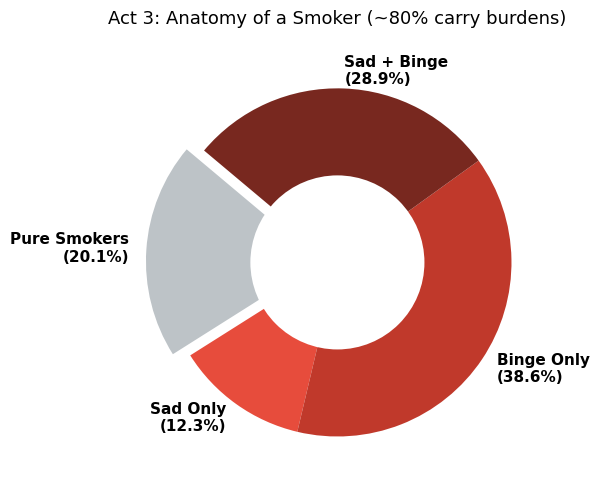

In [16]:
# ==========================================
# 🍩 圖三數據：內部結構 - 吸菸者的解剖
# ==========================================
smokers = df[df['CurrentCigaretteUse_Recoded'] == 1]
total_smokers = len(smokers)
c_pure = len(smokers[(smokers['SadOrHopeless_Recoded']==0) & (smokers['CurrentBingeDrinking5OrMore_Recoded']==0)]) / total_smokers * 100
c_sad_only = len(smokers[(smokers['SadOrHopeless_Recoded']==1) & (smokers['CurrentBingeDrinking5OrMore_Recoded']==0)]) / total_smokers * 100
c_binge_only = len(smokers[(smokers['SadOrHopeless_Recoded']==0) & (smokers['CurrentBingeDrinking5OrMore_Recoded']==1)]) / total_smokers * 100
c_both = len(smokers[(smokers['SadOrHopeless_Recoded']==1) & (smokers['CurrentBingeDrinking5OrMore_Recoded']==1)]) / total_smokers * 100

fig3, ax3 = plt.subplots(figsize=(6, 5))
labels_3 = [f'Pure Smokers\n({c_pure:.1f}%)',
            f'Sad Only\n({c_sad_only:.1f}%)',
            f'Binge Only\n({c_binge_only:.1f}%)',
            f'Sad + Binge\n({c_both:.1f}%)']
sizes_3 = [c_pure, c_sad_only, c_binge_only, c_both]
colors_3 = ['#bdc3c7', '#e74c3c', '#c0392b', '#78281f'] # 顏色與圖二完美對應
explode = (0.1, 0, 0, 0)  # 突顯出那少數的「純粹吸菸者」

wedges, texts = ax3.pie(sizes_3, explode=explode, labels=labels_3, colors=colors_3,
                        startangle=140, textprops={'fontsize': 11, 'fontweight':'bold'})

centre_circle = plt.Circle((0,0),0.50,fc='white')
fig3.gca().add_artist(centre_circle)

ax3.set_title('Act 3: Anatomy of a Smoker (~80% carry burdens)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/act3_donut.png', dpi=300)

plt.show()

This chart focuses exclusively on the "student smoking population," analyzing the proportion of these smokers carrying the burdens of psychological sadness and alcohol dependency.

This is the most striking finding of the project. While the public often assumes smoking stems from rebellion, pure smokers account for only 20.1%. The reality is that nearly 80% of student smokers grapple with psychological sadness or alcohol dependency. This shatters stereotypes, demonstrating that smoking cessation programs must be integrated with mental health and substance abuse support to be truly effective. Cigarettes often serve as a silent outlet for their invisible burdens.


---
這張圖聚焦於「全校吸菸群體」，分析這些吸菸學生內部，分別有多少比例背負著心理悲傷與酒精依賴的負擔。

這是本專案最震撼的發現。大眾常認為青少年抽菸是出於叛逆或跟風（純粹吸菸者僅佔 20.1%），但這張圖呈現了完全不同的真相：近 80% 的吸菸學生，其實同時受到悲傷情緒或酒精問題的困擾。這張圖打破了刻板印象，證明菸害防制若不結合心理輔導與酒精濫用防治，將無法真正解決青少年的吸菸問題。香菸，往往是他們隱形壓力的出口。
